# COVID Mortality -- Domain-Anchored Causal Plausibility Filter (DACPF) -- Local Runner

**Research Question:** Can the Domain-Anchored Causal Plausibility Filter (DACPF) improve over standard CTGAN augmentation for COVID mortality prediction?

**Causal Anchors:**
| Anchor | Type | Causal Rationale |
|--------|------|------------------|
| `idade` | continuous | Age is the strongest single predictor of COVID death |
| `motivo_cancer` | binary | Cancer severely compromises immune response to COVID |
| `motivo_respiratorio` | binary | Respiratory conditions are direct risk factors for COVID death |

**Experimental Conditions:**
| Condition | Description |
|-----------|-------------|
| `baseline` | No augmentation |
| `ctgan_standard` | CTGAN minority-only, no filter |
| `dacpf_age` | CTGAN + filter on `idade` only |
| `dacpf_disease` | CTGAN + filter on `motivo_cancer` + `motivo_respiratorio` |
| `dacpf_combined` | CTGAN + all 3 anchors (full DACPF) |

**Note:** This is a local-runnable version (no google.colab dependencies).

In [1]:
# == Cell 1: Imports ==
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency, t as t_dist

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KernelDensity

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

from catboost import CatBoostClassifier
from xgboost import XGBClassifier

try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
    print('TabPFN available')
except Exception:
    TABPFN_AVAILABLE = False
    print('TabPFN not available -- will skip TabPFN condition')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Imports complete')

TabPFN not available -- will skip TabPFN condition
Imports complete


In [2]:
# == Cell 2: Configuration ==

# Update DATA_PATH to match your local file location
DATA_PATH  = 'banco_covidIH.xlsx'
TARGET_COL = 'obito'

COVID_FEATURES = [
    'idade', 'sexo', 'etilismo', 'tabagismo',
    'motivo_cancer', 'motivo_msk', 'motivo_digestivo2', 'motivo_cardio2',
    'motivo_procedimentos2', 'motivo_lesao2', 'motivo_respiratorio', 'motivo_neuro',
    'motivo_pele', 'motivo_genitourinaria', 'motivo_dm', 'motivo_mental_subst',
    'motivo_infec2', 'motivo_propedeutica',
    'n_comorbidades', 'comorb_hipertensao', 'comorb_ic', 'comorb_dac',
    'comorb_fibrilacao', 'comorb_avc', 'comorb_dpoc', 'comorb_asma',
    'comorb_dm', 'comorb_obesidade', 'comorb_drc', 'comorb_cancer',
    'comorb_reumatologica', 'comorb_cirrose', 'comorb_hiv'
]

# CTGAN: fits on minority class only (deaths)
CTGAN_EPOCHS      = 150
FIT_MINORITY_ONLY = True
POOL_MULT         = 8    # larger pool because dataset is small
SYNTH_BATCH       = 5.0
N_FOLDS           = 5

# Causal anchors
CAUSAL_ANCHORS = [
    {'col': 'idade',               'type': 'continuous', 'label': 'Age (Idade)'},
    {'col': 'motivo_cancer',       'type': 'binary',     'label': 'Cancer Reason'},
    {'col': 'motivo_respiratorio', 'type': 'binary',     'label': 'Respiratory Reason'},
]

ABLATION_GROUPS = {
    'dacpf_age':      ['idade'],
    'dacpf_disease':  ['motivo_cancer', 'motivo_respiratorio'],
    'dacpf_combined': ['idade', 'motivo_cancer', 'motivo_respiratorio'],
}

DACPF_TEMPERATURE = 2.0
KDE_BANDWIDTH     = 'scott'

print('Configuration set')
print(f'  Target      : {TARGET_COL}')
print(f'  CTGAN mode  : minority-only, {CTGAN_EPOCHS} epochs')
print(f'  Anchors     : {[a["col"] for a in CAUSAL_ANCHORS]}')

Configuration set
  Target      : obito
  CTGAN mode  : minority-only, 150 epochs
  Anchors     : ['idade', 'motivo_cancer', 'motivo_respiratorio']


In [3]:
# == Cell 3: Data loading ==
df_raw = pd.read_excel(DATA_PATH)
cols_to_use = [c for c in COVID_FEATURES if c in df_raw.columns] + [TARGET_COL]
df = df_raw[cols_to_use].dropna(subset=[TARGET_COL]).copy()
df[TARGET_COL] = df[TARGET_COL].astype(int)

print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} cols')
print(df[TARGET_COL].value_counts())

minority_class = int(df[TARGET_COL].value_counts().idxmin())
majority_class = int(df[TARGET_COL].value_counts().idxmax())
print(f'\nMinority (death): {minority_class} | Majority (survived): {majority_class}')

print('\n--- Causal anchor check ---')
for anchor in CAUSAL_ANCHORS:
    col = anchor['col']
    if col in df.columns:
        print(f'  OK  {col!r}  dtype={df[col].dtype}  nulls={df[col].isna().sum()}')
    else:
        close = [c for c in df.columns if anchor['col'].split('_')[-1] in c.lower()]
        print(f'  MISSING  {col!r} -- possible matches: {close[:5]}')

Dataset: 334 rows x 34 cols
obito
0    251
1     83
Name: count, dtype: int64

Minority (death): 1 | Majority (survived): 0

--- Causal anchor check ---
  OK  'idade'  dtype=int64  nulls=0
  OK  'motivo_cancer'  dtype=int64  nulls=0
  OK  'motivo_respiratorio'  dtype=int64  nulls=0


## Section 1 -- Causal Anchor Distribution Analysis

Check that each anchor has a meaningfully different distribution between
survivors (majority) and deaths (minority).

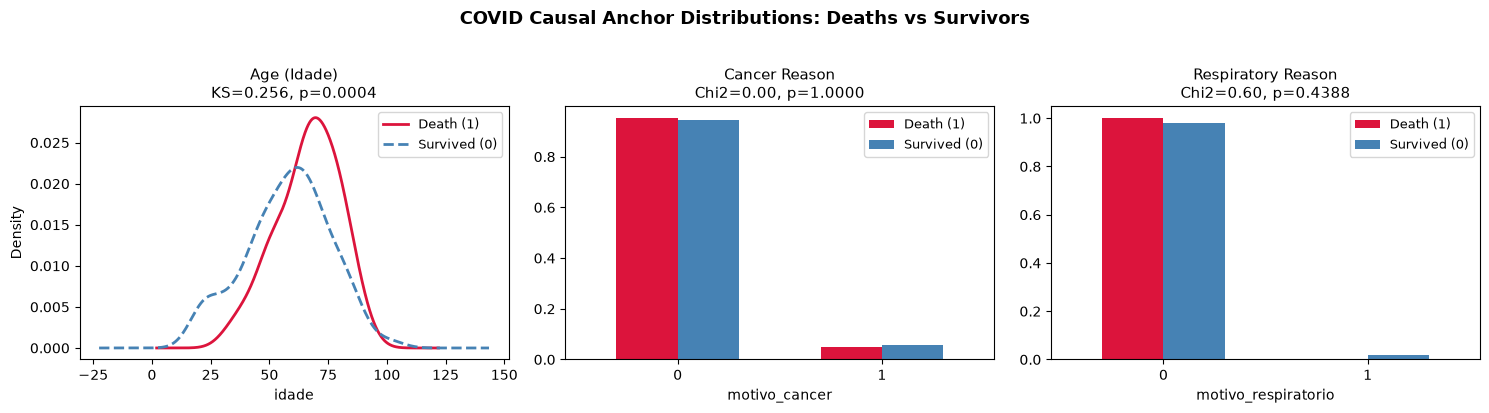

             anchor test     stat        p
              idade   KS 0.256180 0.000423
      motivo_cancer Chi2 0.000000 1.000000
motivo_respiratorio Chi2 0.599421 0.438799


In [4]:
# == Cell 4: Anchor distribution analysis ==
valid_anchors = [a for a in CAUSAL_ANCHORS if a['col'] in df.columns]
fig, axes = plt.subplots(1, len(valid_anchors), figsize=(5 * len(valid_anchors), 4))
if len(valid_anchors) == 1:
    axes = [axes]

minority_df = df[df[TARGET_COL] == minority_class]
majority_df = df[df[TARGET_COL] == majority_class]
anchor_stats = []

for ax, anchor in zip(axes, valid_anchors):
    col = anchor['col']
    if anchor['type'] == 'continuous':
        minority_df[col].dropna().plot.kde(ax=ax, label='Death (1)', color='crimson', lw=2)
        majority_df[col].dropna().plot.kde(ax=ax, label='Survived (0)', color='steelblue',
                                            lw=2, linestyle='--')
        ks_stat, ks_p = ks_2samp(minority_df[col].dropna(), majority_df[col].dropna())
        anchor_stats.append({'anchor': col, 'test': 'KS', 'stat': ks_stat, 'p': ks_p})
        ax.set_title(f'{anchor["label"]}\nKS={ks_stat:.3f}, p={ks_p:.4f}', fontsize=11)
    else:
        cts = pd.DataFrame({
            'Death (1)':    minority_df[col].value_counts(normalize=True),
            'Survived (0)': majority_df[col].value_counts(normalize=True),
        }).fillna(0)
        cts.plot.bar(ax=ax, color=['crimson', 'steelblue'], width=0.6)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        ct = pd.crosstab(df[col], df[TARGET_COL])
        chi2, chi2_p = chi2_contingency(ct)[:2]
        anchor_stats.append({'anchor': col, 'test': 'Chi2', 'stat': chi2, 'p': chi2_p})
        ax.set_title(f'{anchor["label"]}\nChi2={chi2:.2f}, p={chi2_p:.4f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlabel(col)

plt.suptitle('COVID Causal Anchor Distributions: Deaths vs Survivors', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('covid_anchor_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print(pd.DataFrame(anchor_stats).to_string(index=False))

## Section 2 -- DACPF Implementation

Scoring algorithm:
- **`idade`** (continuous): KDE density fitted on real death cases
- **`motivo_cancer`** (binary): P(motivo_cancer = v | death) from real data
- **`motivo_respiratorio`** (binary): P(motivo_respiratorio = v | death) from real data

Temperature parameter sharpens the selection probability distribution --
higher temperature = more aggressive filtering toward high-plausibility samples.

In [5]:
# == Cell 5: DACPF scorer ==

def build_dacpf_scorer(real_minority_df, active_anchor_cols):
    """Build a scoring function over a pool of synthetic candidates.
    
    Returns a function that, given a pool DataFrame, computes normalised
    selection weights based on causal plausibility relative to real deaths.
    """
    scorers = {}
    for anchor in CAUSAL_ANCHORS:
        col = anchor['col']
        if col not in active_anchor_cols or col not in real_minority_df.columns:
            continue
        vals = real_minority_df[col].dropna().values
        if len(vals) < 3:
            print(f'  Warning: too few values for anchor {col!r}, skipping')
            continue
        if anchor['type'] == 'continuous':
            kde = KernelDensity(bandwidth=KDE_BANDWIDTH, kernel='gaussian')
            kde.fit(vals.reshape(-1, 1))
            scorers[col] = ('kde', kde, float(real_minority_df[col].median()))
        else:
            prob_map = real_minority_df[col].value_counts(normalize=True).to_dict()
            scorers[col] = ('cat', prob_map)

    def _score_pool(pool_df):
        n = len(pool_df)
        log_scores = np.zeros(n)
        for col, sinfo in scorers.items():
            if col not in pool_df.columns:
                continue
            if sinfo[0] == 'kde':
                fill_val = sinfo[2]  # median fallback for NaN
                vals = pool_df[col].fillna(fill_val).values.reshape(-1, 1)
                ld = sinfo[1].score_samples(vals)
                log_scores += ld - ld.min()
            else:
                prob_map = sinfo[1]
                probs = np.array([prob_map.get(v, 1e-9) for v in pool_df[col].fillna(-999)])
                log_scores += np.log(probs + 1e-12)
        log_scores -= log_scores.max()
        w = np.exp(log_scores)
        return w / (w.sum() + 1e-12)

    return _score_pool


def dacpf_select(pool_df, need, scorer_fn, temperature=DACPF_TEMPERATURE):
    """Sample `need` rows from pool_df weighted by causal plausibility scores."""
    w = scorer_fn(pool_df)
    w = np.power(w + 1e-12, temperature)
    w = w / w.sum()
    n_select = min(need, len(pool_df))
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(pool_df), size=n_select, replace=False, p=w)
    return pool_df.iloc[idx].reset_index(drop=True)


print('DACPF scorer ready')

DACPF scorer ready


In [6]:
# == Cell 6: Augmentation pipelines ==

def _build_ctgan_pool(train_df, minority_cls, need):
    """Fit CTGAN on minority class and generate a pool of need * POOL_MULT candidates."""
    fit_data = train_df[train_df[TARGET_COL] == minority_cls] if FIT_MINORITY_ONLY else train_df

    meta = SingleTableMetadata()
    meta.detect_from_dataframe(data=fit_data)
    meta.update_column(TARGET_COL, sdtype='categorical')
    ctgan = CTGANSynthesizer(meta, epochs=CTGAN_EPOCHS, verbose=False)
    ctgan.fit(fit_data)

    target_size = need * POOL_MULT
    collected = []
    while sum(len(x) for x in collected) < target_size:
        batch_n = int(len(fit_data) * SYNTH_BATCH)
        synth = ctgan.sample(num_rows=max(batch_n, 50))
        collected.append(synth[synth[TARGET_COL] == minority_cls])

    pool = pd.concat(collected, ignore_index=True)
    return pool.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


def augment_ctgan_standard(train_df):
    vc = train_df[TARGET_COL].value_counts()
    majority, minority = vc.idxmax(), vc.idxmin()
    need = int(vc[majority] - vc[minority])
    if need <= 0:
        return train_df
    pool = _build_ctgan_pool(train_df, minority, need)
    synth_used = pool.sample(n=min(need, len(pool)), random_state=RANDOM_STATE)
    return pd.concat([train_df, synth_used], ignore_index=True)


def augment_dacpf(train_df, active_anchor_cols):
    vc = train_df[TARGET_COL].value_counts()
    majority, minority = vc.idxmax(), vc.idxmin()
    need = int(vc[majority] - vc[minority])
    if need <= 0:
        return train_df
    real_minority = train_df[train_df[TARGET_COL] == minority]
    scorer = build_dacpf_scorer(real_minority, active_anchor_cols)
    pool = _build_ctgan_pool(train_df, minority, need)
    synth_used = dacpf_select(pool, need, scorer)
    return pd.concat([train_df, synth_used], ignore_index=True)


def augment_dacpf_age(train_df):      return augment_dacpf(train_df, ABLATION_GROUPS['dacpf_age'])
def augment_dacpf_disease(train_df):  return augment_dacpf(train_df, ABLATION_GROUPS['dacpf_disease'])
def augment_dacpf_combined(train_df): return augment_dacpf(train_df, ABLATION_GROUPS['dacpf_combined'])


AUGMENT_PIPELINES = {
    'baseline':       lambda df: df,
    'ctgan_standard': augment_ctgan_standard,
    'dacpf_age':      augment_dacpf_age,
    'dacpf_disease':  augment_dacpf_disease,
    'dacpf_combined': augment_dacpf_combined,
}

print('Augmentation pipelines ready:')
for k in AUGMENT_PIPELINES:
    print(f'  {k}')

Augmentation pipelines ready:
  baseline
  ctgan_standard
  dacpf_age
  dacpf_disease
  dacpf_combined


In [7]:
# == Cell 7: Models + preprocessor ==

def build_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    return ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ], verbose_feature_names_out=False)


def get_models():
    models = {
        'CatBoost': CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.05,
            loss_function='Logloss', verbose=False, random_seed=RANDOM_STATE),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric='logloss', tree_method='hist', random_state=RANDOM_STATE),
    }
    if TABPFN_AVAILABLE:
        models['TabPFN'] = TabPFNClassifier(device='cpu', ignore_pretraining_limits=True)
    return models


def mean_ci(values, conf=0.95):
    v = np.array(values, dtype=float)
    n, m, s = len(v), v.mean(), v.std(ddof=1)
    tcrit = t_dist.ppf(1 - (1 - conf) / 2, df=n - 1)
    return m, tcrit * s / np.sqrt(n)


print('Models ready:', list(get_models().keys()))

Models ready: ['CatBoost', 'XGBoost']


## Section 3 -- 5-Fold Cross-Validation

5 conditions x 5 folds x models = evaluations per model.

Note: COVID is a small dataset (~334 rows). Each fold has ~267 training rows
with only ~67 minority (death) cases to fit CTGAN on.

In [8]:
# == Cell 8: Cross-validation runner ==

def run_cv(df_in, n_folds=N_FOLDS, verbose=True):
    X = df_in.drop(columns=[TARGET_COL])
    y = df_in[TARGET_COL].astype(int)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    results = []

    for cond_name, aug_fn in AUGMENT_PIPELINES.items():
        if verbose:
            print(f'\n{"="*60}')
            print(f'Condition: {cond_name}')
            print(f'{"="*60}')

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
            if verbose:
                print(f'  Fold {fold}/{n_folds} ...', end=' ', flush=True)

            Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
            ytr, yva = y.iloc[tr_idx], y.iloc[va_idx]

            train_df = Xtr.copy()
            train_df[TARGET_COL] = ytr.values
            train_aug = aug_fn(train_df)

            prep = build_preprocessor(train_aug.drop(columns=[TARGET_COL]))
            Xtr_p = prep.fit_transform(train_aug.drop(columns=[TARGET_COL]))
            Xva_p = prep.transform(Xva)
            ytr_aug = train_aug[TARGET_COL].astype(int).values

            for mname, model in get_models().items():
                try:
                    if mname == 'TabPFN':
                        model.fit(np.asarray(Xtr_p), ytr_aug)
                        preds = model.predict(np.asarray(Xva_p))
                    else:
                        model.fit(Xtr_p, ytr_aug)
                        preds = model.predict(Xva_p)

                    f1 = f1_score(yva, preds, average='macro')
                    results.append({'condition': cond_name, 'model': mname,
                                    'fold': fold, 'macro_f1': f1})
                    if verbose:
                        print(f'[{mname}: {f1:.4f}]', end='  ')
                except Exception as e:
                    print(f'\n  [{mname} fold {fold} ERROR]: {e}')
            if verbose:
                print()

    return pd.DataFrame(results)


print('CV runner ready')

CV runner ready


In [9]:
# == Cell 9: Execute CV ==
print('Starting COVID DACPF 5-fold CV')
print(f'Dataset: {df.shape} | Target: {TARGET_COL} | CTGAN: minority-only, {CTGAN_EPOCHS} epochs')

results_df = run_cv(df, n_folds=N_FOLDS, verbose=True)

results_df.to_csv('covid_dacpf_raw_results.csv', index=False)
print('\nDone. Saved: covid_dacpf_raw_results.csv')

Starting COVID DACPF 5-fold CV
Dataset: (334, 34) | Target: obito | CTGAN: minority-only, 150 epochs

Condition: baseline
  Fold 1/5 ... 

[CatBoost: 0.4787]  [XGBoost: 0.6014]  
  Fold 2/5 ... 

[CatBoost: 0.4924]  [XGBoost: 0.4562]  
  Fold 3/5 ... 

[CatBoost: 0.4666]  [XGBoost: 0.4345]  
  Fold 4/5 ... 

[CatBoost: 0.5379]  [XGBoost: 0.4876]  
  Fold 5/5 ... 

...

[CatBoost: 0.5594]  [XGBoost: 0.5705]  
  Fold 2/5 ... 

[CatBoost: 0.6181]  [XGBoost: 0.5819]  
  Fold 3/5 ... 

[CatBoost: 0.4201]  [XGBoost: 0.5117]  
  Fold 4/5 ... 

[CatBoost: 0.5479]  [XGBoost: 0.4553]  
  Fold 5/5 ... 

[CatBoost: 0.4826]  [XGBoost: 0.4826]  

Done. Saved: covid_dacpf_raw_results.csv


## Section 4 -- Results Summary

In [10]:
# == Cell 10: Results table ==
summary_rows = []
for (condition, model), g in results_df.groupby(['condition', 'model']):
    m, ci = mean_ci(g['macro_f1'].values)
    bl = results_df[(results_df['condition'] == 'baseline') &
                    (results_df['model'] == model)]['macro_f1'].mean()
    std_ctgan = results_df[(results_df['condition'] == 'ctgan_standard') &
                           (results_df['model'] == model)]['macro_f1'].mean()
    summary_rows.append({
        'Condition': condition, 'Model': model,
        'Mean F1': f'{m:.4f}', '+/- 95% CI': f'{ci:.4f}',
        'Delta vs Baseline': f'{m - bl:+.4f}',
        'Delta vs Std CTGAN': f'{m - std_ctgan:+.4f}',
        '_mean': m, '_delta_bl': m - bl, '_delta_ctgan': m - std_ctgan,
    })

summary_df = pd.DataFrame(summary_rows)
ORDER = ['baseline', 'ctgan_standard', 'dacpf_age', 'dacpf_disease', 'dacpf_combined']

print('=' * 80)
print('COVID DACPF RESULTS (5-fold CV mean +/- 95% CI)')
print('=' * 80)
disp = (summary_df[['Condition', 'Model', 'Mean F1', '+/- 95% CI', 'Delta vs Baseline', 'Delta vs Std CTGAN']]
        .sort_values(['Model', 'Condition']).set_index(['Model', 'Condition']))
print(disp.to_string())

print('\n--- Best condition per model ---')
for model, grp in summary_df.groupby('Model'):
    best = grp.loc[grp['_mean'].idxmax()]
    d_ctgan = best['_delta_ctgan']
    verdict = ('DACPF adds further gain' if float(d_ctgan) > 0.005
               else ('similar to Std CTGAN' if abs(float(d_ctgan)) <= 0.005
                     else 'Std CTGAN better'))
    print(f'  {model:10s}: {best["Condition"]:22s} F1={best["_mean"]:.4f}  '
          f'vs Std CTGAN: {d_ctgan}  --> {verdict}')

summary_df.to_csv('covid_dacpf_summary.csv', index=False)
print('\nSaved: covid_dacpf_summary.csv')

COVID DACPF RESULTS (5-fold CV mean +/- 95% CI)
                        Mean F1 +/- 95% CI Delta vs Baseline Delta vs Std CTGAN
Model    Condition                                                             
CatBoost baseline        0.4740     0.0646           +0.0000            -0.0522
         ctgan_standard  0.5262     0.0732           +0.0522            +0.0000
         dacpf_age       0.5257     0.0922           +0.0517            -0.0005
         dacpf_combined  0.5256     0.0945           +0.0516            -0.0006
         dacpf_disease   0.5771     0.0654           +0.1030            +0.0508
XGBoost  baseline        0.4759     0.0957           +0.0000            -0.0496
         ctgan_standard  0.5255     0.0732           +0.0496            +0.0000
         dacpf_age       0.4983     0.0662           +0.0224            -0.0272
         dacpf_combined  0.5204     0.0681           +0.0445            -0.0051
         dacpf_disease   0.5339     0.0634           +0.0580            

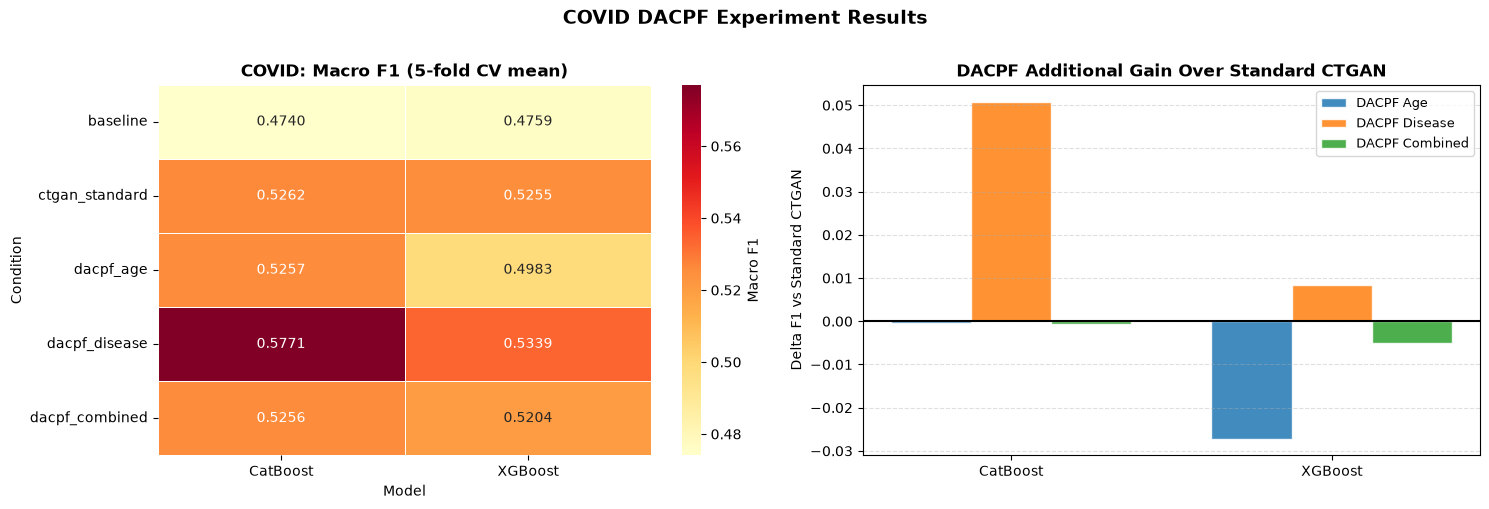

Saved: covid_dacpf_results.png


In [11]:
# == Cell 11: Results visualisation ==
MODELS = [m for m in ['CatBoost', 'XGBoost', 'TabPFN'] if m in results_df['model'].unique()]
COLORS = {'dacpf_age': '#1f77b4', 'dacpf_disease': '#ff7f0e',
          'dacpf_combined': '#2ca02c', 'ctgan_standard': '#d62728'}
LABELS = {'dacpf_age': 'DACPF Age', 'dacpf_disease': 'DACPF Disease',
          'dacpf_combined': 'DACPF Combined', 'ctgan_standard': 'Std CTGAN'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A: F1 heatmap
heat = (summary_df.pivot_table(index='Condition', columns='Model', values='_mean')
        .reindex([o for o in ORDER if o in summary_df['Condition'].unique()])
        .reindex(columns=MODELS).astype(float))
sns.heatmap(heat, ax=axes[0], annot=True, fmt='.4f',
            cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Macro F1'})
axes[0].set_title('COVID: Macro F1 (5-fold CV mean)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

# Panel B: Delta vs Std CTGAN
delta_df = summary_df[summary_df['Condition'].isin(['dacpf_age', 'dacpf_disease', 'dacpf_combined'])].copy()
x = np.arange(len(MODELS))
width = 0.25
offsets = {'dacpf_age': -1, 'dacpf_disease': 0, 'dacpf_combined': 1}
for cond, offset in offsets.items():
    sub = delta_df[delta_df['Condition'] == cond]
    vals = [float(sub[sub['Model'] == m]['_delta_ctgan'].values[0])
            if not sub[sub['Model'] == m].empty else 0 for m in MODELS]
    axes[1].bar(x + offset * width, vals, width=width,
                color=COLORS.get(cond, 'grey'), label=LABELS.get(cond, cond),
                alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(MODELS)
axes[1].set_ylabel('Delta F1 vs Standard CTGAN')
axes[1].set_title('DACPF Additional Gain Over Standard CTGAN', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.4, linestyle='--')

plt.suptitle('COVID DACPF Experiment Results', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('covid_dacpf_results.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: covid_dacpf_results.png')

## Section 5 -- Filter Quality Diagnostics

Verify that DACPF actually improves distributional alignment between
synthetic and real death cases -- independent of F1 results.

Generating diagnostic pool (fold 1)...
  Training split: 267 rows | death cases: 67 | need: 133


  Pool: 1340 | Selected: 133


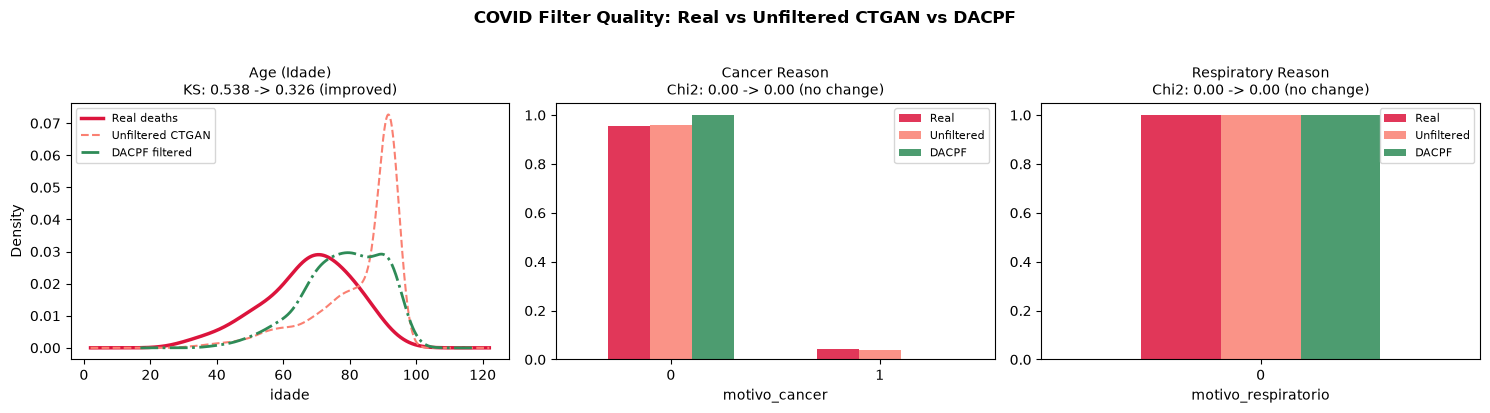

             anchor metric  before    after   delta
              idade     KS 0.53806 0.325889 0.21217
      motivo_cancer   Chi2 0.00000 0.000000 0.00000
motivo_respiratorio   Chi2 0.00000 0.000000 0.00000

Positive delta = filter improved alignment with real death cases
Saved: covid_dacpf_filter_quality.png


In [12]:
# == Cell 12: Filter quality diagnostics ==
print('Generating diagnostic pool (fold 1)...')

X_d = df.drop(columns=[TARGET_COL])
y_d = df[TARGET_COL].astype(int)
skf_d = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
tr_idx_d, _ = next(iter(skf_d.split(X_d, y_d)))

train_d  = df.iloc[tr_idx_d].copy()
vc_d     = train_d[TARGET_COL].value_counts()
maj_d    = int(vc_d.idxmax())
min_d    = int(vc_d.idxmin())
need_d   = int(vc_d[maj_d] - vc_d[min_d])
real_min = train_d[train_d[TARGET_COL] == min_d]
print(f'  Training split: {len(train_d)} rows | death cases: {len(real_min)} | need: {need_d}')

pool_d     = _build_ctgan_pool(train_d, min_d, need_d)
scorer_d   = build_dacpf_scorer(real_min, ABLATION_GROUPS['dacpf_combined'])
filtered_d = dacpf_select(pool_d, need_d, scorer_d)
print(f'  Pool: {len(pool_d)} | Selected: {len(filtered_d)}')

valid_a = [a for a in CAUSAL_ANCHORS if a['col'] in df.columns]
fig, axes = plt.subplots(1, len(valid_a), figsize=(5 * len(valid_a), 4))
if len(valid_a) == 1:
    axes = [axes]

diag_stats = []
for ax, anchor in zip(axes, valid_a):
    col = anchor['col']
    rv = real_min[col].dropna()
    uv = pool_d[col].dropna()
    fv = filtered_d[col].dropna()

    if anchor['type'] == 'continuous':
        rv.plot.kde(ax=ax, label='Real deaths', color='crimson', lw=2.5)
        uv.plot.kde(ax=ax, label='Unfiltered CTGAN', color='salmon', lw=1.5, ls='--')
        fv.plot.kde(ax=ax, label='DACPF filtered', color='seagreen', lw=2, ls='-.')
        ks_b = ks_2samp(rv, uv).statistic
        ks_a = ks_2samp(rv, fv).statistic
        improved = 'improved' if ks_a < ks_b else 'no change'
        ax.set_title(f'{anchor["label"]}\nKS: {ks_b:.3f} -> {ks_a:.3f} ({improved})', fontsize=10)
        diag_stats.append({'anchor': col, 'metric': 'KS', 'before': ks_b, 'after': ks_a, 'delta': ks_b - ks_a})
    else:
        df_cmp = pd.DataFrame({
            'Real': rv.value_counts(normalize=True),
            'Unfiltered': uv.value_counts(normalize=True),
            'DACPF': fv.value_counts(normalize=True),
        }).fillna(0)
        df_cmp.plot.bar(ax=ax, color=['crimson', 'salmon', 'seagreen'], width=0.6, alpha=0.85)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        try:
            chi_b = chi2_contingency(pd.crosstab(pd.concat([rv, uv]),
                               pd.Series(['r'] * len(rv) + ['s'] * len(uv))))[0]
            chi_a = chi2_contingency(pd.crosstab(pd.concat([rv, fv]),
                               pd.Series(['r'] * len(rv) + ['s'] * len(fv))))[0]
        except Exception:
            chi_b, chi_a = 0.0, 0.0
        improved = 'improved' if chi_a < chi_b else 'no change'
        ax.set_title(f'{anchor["label"]}\nChi2: {chi_b:.2f} -> {chi_a:.2f} ({improved})', fontsize=10)
        diag_stats.append({'anchor': col, 'metric': 'Chi2', 'before': chi_b, 'after': chi_a, 'delta': chi_b - chi_a})
    ax.legend(fontsize=8)
    ax.set_xlabel(col)

plt.suptitle('COVID Filter Quality: Real vs Unfiltered CTGAN vs DACPF',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('covid_dacpf_filter_quality.png', bbox_inches='tight', dpi=150)
plt.show()

print(pd.DataFrame(diag_stats).to_string(index=False))
print('\nPositive delta = filter improved alignment with real death cases')
print('Saved: covid_dacpf_filter_quality.png')

## Section 6 -- Ablation: Marginal Anchor Contributions

In [13]:
# == Cell 13: Ablation -- marginal anchor contributions ==
PAIRS = [
    ('ctgan_standard', 'dacpf_age',      'Age anchor vs Std CTGAN'),
    ('ctgan_standard', 'dacpf_disease',  'Disease anchors vs Std CTGAN'),
    ('ctgan_standard', 'dacpf_combined', 'Full DACPF vs Std CTGAN'),
    ('dacpf_age',      'dacpf_combined', 'Adding disease to age'),
    ('dacpf_disease',  'dacpf_combined', 'Adding age to disease'),
]

model_list = [m for m in ['CatBoost', 'XGBoost', 'TabPFN'] if m in results_df['model'].unique()]
print('\n--- COVID Ablation: Delta F1 (positive = improvement over reference) ---')
header = f'{"Comparison":<38}  ' + '  '.join(f'{m:>10}' for m in model_list)
print(header)
print('-' * len(header))

abl_rows = []
for base_c, tgt_c, label in PAIRS:
    row = {'Comparison': label}
    vals = []
    for model in model_list:
        bm = results_df[(results_df.condition == base_c) & (results_df.model == model)]['macro_f1'].mean()
        tm = results_df[(results_df.condition == tgt_c)  & (results_df.model == model)]['macro_f1'].mean()
        row[model] = f'{tm - bm:+.4f}'
        vals.append(f'{tm - bm:+.4f}')
    abl_rows.append(row)
    print(f'  {label:<36}  ' + '  '.join(f'{v:>10}' for v in vals))

pd.DataFrame(abl_rows).to_csv('covid_dacpf_ablation.csv', index=False)
print('\nSaved: covid_dacpf_ablation.csv')


--- COVID Ablation: Delta F1 (positive = improvement over reference) ---
Comparison                                CatBoost     XGBoost
--------------------------------------------------------------
  Age anchor vs Std CTGAN                  -0.0005     -0.0272
  Disease anchors vs Std CTGAN             +0.0508     +0.0084
  Full DACPF vs Std CTGAN                  -0.0006     -0.0051
  Adding disease to age                    -0.0001     +0.0221
  Adding age to disease                    -0.0514     -0.0135

Saved: covid_dacpf_ablation.csv


## Section 7 -- Final Interpretation Summary

In [14]:
# == Cell 14: Final summary ==
print('=' * 72)
print('COVID DACPF -- FINAL INTERPRETATION SUMMARY')
print('=' * 72)

for model in model_list:
    mdf = summary_df[summary_df['Model'] == model].sort_values('_mean', ascending=False)
    best = mdf.iloc[0]
    std  = mdf[mdf['Condition'] == 'ctgan_standard']['_mean'].values
    full = mdf[mdf['Condition'] == 'dacpf_combined']['_mean'].values
    print(f'\n{model}:')
    print(f'  Best condition : {best["Condition"]} (F1={best["_mean"]:.4f})')
    if len(std) and len(full):
        d = float(full[0]) - float(std[0])
        v = ('DACPF adds further gain' if d > 0.005
             else ('similar' if abs(d) <= 0.005 else 'Std CTGAN better'))
        print(f'  DACPF combined vs Std CTGAN: {d:+.4f} --> {v}')

print('\n--- Interpretation Guide ---')
print("""
SCENARIO A -- DACPF helps COVID MORE than Vigitel:
  Filter is maximally effective when combined with a strong CTGAN baseline.

SCENARIO B -- DACPF helps COVID LESS than Vigitel:
  Filter provides diminishing returns when CTGAN is already working well.
  Supports the Cohesion Hypothesis.

SCENARIO C -- DACPF helps both datasets approximately equally:
  Causal anchor filter is universally beneficial -- strongest result for dissertation.

SCENARIO D -- DACPF does not help either dataset:
  Try temperature=3.0 or different anchor combinations.
""")

print('All outputs saved to current directory.')

COVID DACPF -- FINAL INTERPRETATION SUMMARY

CatBoost:
  Best condition : dacpf_disease (F1=0.5771)
  DACPF combined vs Std CTGAN: -0.0006 --> similar

XGBoost:
  Best condition : dacpf_disease (F1=0.5339)
  DACPF combined vs Std CTGAN: -0.0051 --> Std CTGAN better

--- Interpretation Guide ---

SCENARIO A -- DACPF helps COVID MORE than Vigitel:
  Filter is maximally effective when combined with a strong CTGAN baseline.

SCENARIO B -- DACPF helps COVID LESS than Vigitel:
  Filter provides diminishing returns when CTGAN is already working well.
  Supports the Cohesion Hypothesis.

SCENARIO C -- DACPF helps both datasets approximately equally:
  Causal anchor filter is universally beneficial -- strongest result for dissertation.

SCENARIO D -- DACPF does not help either dataset:
  Try temperature=3.0 or different anchor combinations.

All outputs saved to current directory.
